In [1]:
import os
import pathlib

import warnings
warnings.filterwarnings("ignore")

import FunctionLib as FL

import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

from collections import defaultdict

import matplotlib as mpl
import matplotlib.pyplot as plt
config = {
    "font.size": 18,
    "font.family": "serif",
    "figure.figsize": (25, 14),

    "axes.titlesize": 28,
    "axes.labelsize": 24,
    "legend.fontsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,

    "axes.linewidth": 2,
    "axes.edgecolor": "black",

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.width": 2,
    "ytick.minor.width": 2,

    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
}
mpl.rcParams.update(config)

import astropy.units as u
import astropy

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(("./DJAV4.2Catalog.pkl"))

print("="*50)
print(f"Total {(DJAv4Catalog.sample_num())} sample objectss loaded.")
print("="*50)

Total 1102 sample objectss loaded.


Selected 1102 targets for analysis.
Categorizing 1102 objects...
Group 0: 102 objects, Mean BD=0.000
Group 1: 148 objects, Mean BD=0.062
Group 2: 150 objects, Mean BD=0.147
Group 3: 111 objects, Mean BD=0.246
Group 4: 69 objects, Mean BD=0.363
Group 5: 44 objects, Mean BD=0.517
Group 6: 34 objects, Mean BD=0.731

Computing average spectra...
Applied masks to 8 regions.
  Group 0: Processed.
Applied masks to 8 regions.
  Group 1: Processed.
Applied masks to 8 regions.
  Group 2: Processed.
Applied masks to 8 regions.
  Group 3: Processed.
Applied masks to 8 regions.
  Group 4: Processed.
Applied masks to 8 regions.
  Group 5: Processed.
Applied masks to 8 regions.
  Group 6: Processed.
Reference spectrum smoothed.
Computed effective curve and errors using smoothed reference.
Error propagation successful. Ready for MCMC.
Running MCMC with 32 walkers for 3000 steps (Monotonicity Constrained)...


 10%|█         | 311/3000 [00:00<00:04, 561.40it/s]

100%|██████████| 3000/3000 [00:05<00:00, 591.93it/s]


MCMC Best Fit Coeffs: [ 0.00806459 -0.18915066  1.48700735 -2.12323845]


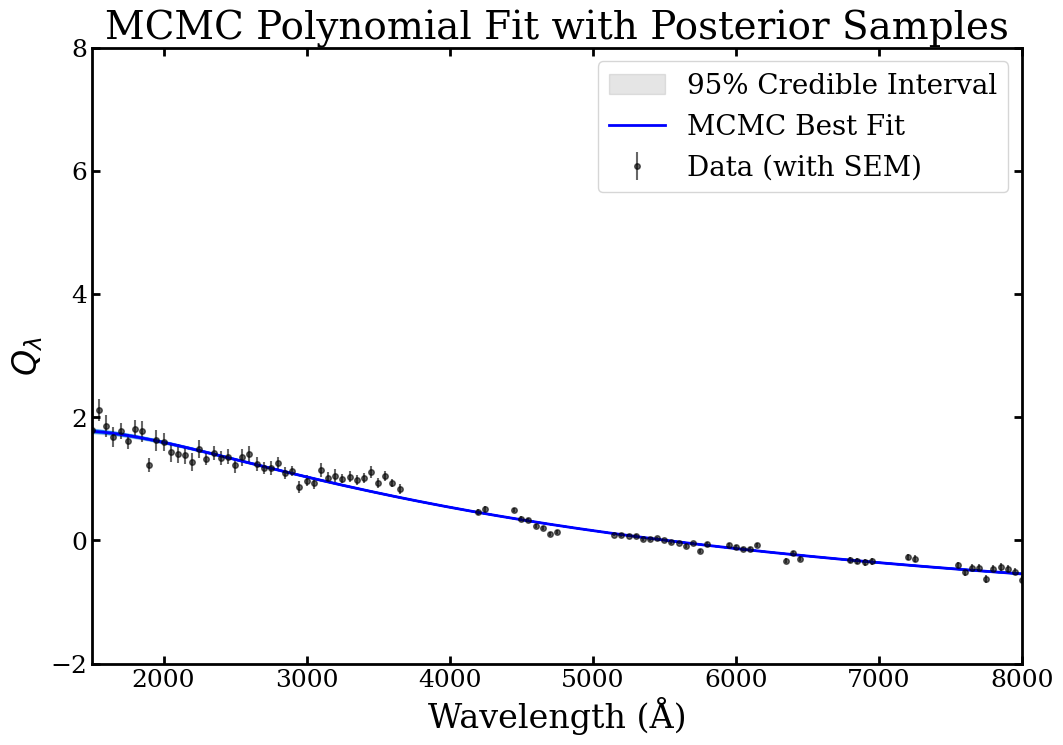

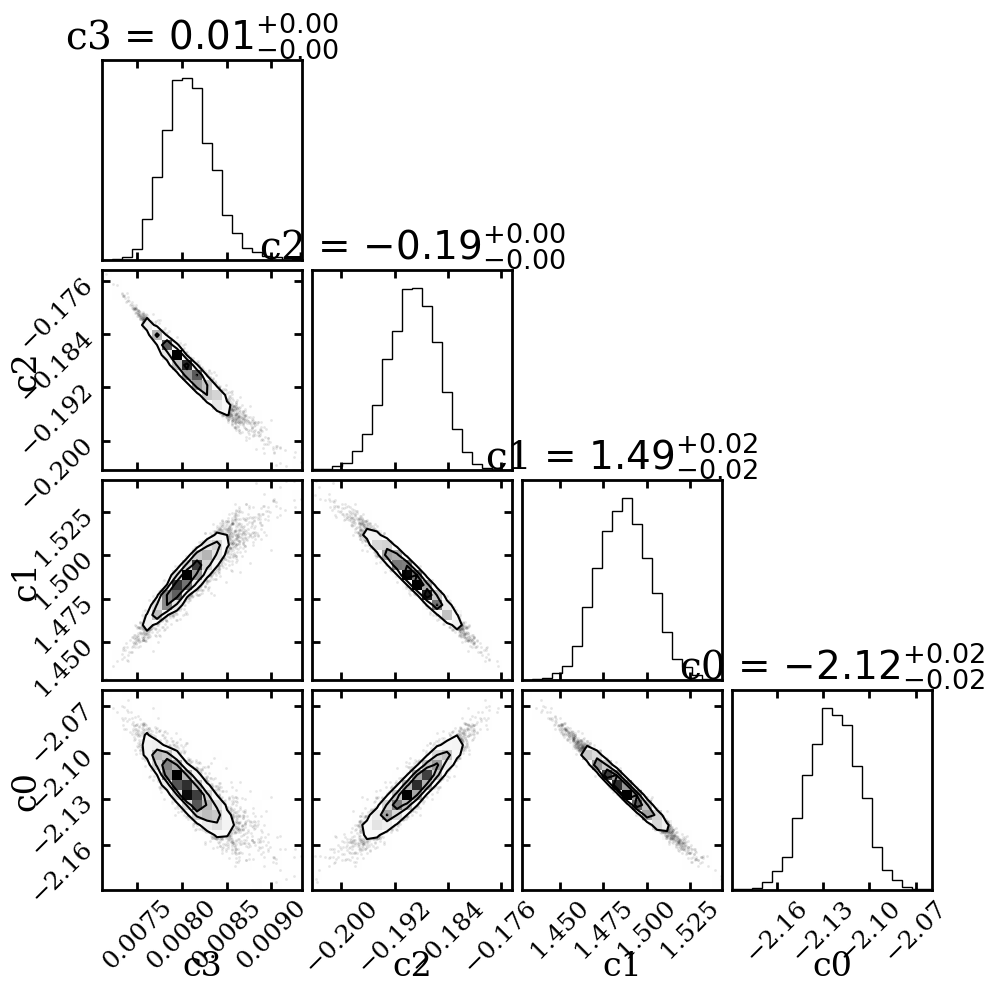

Derived Parameters: S=2.6999, Intercept=-0.89877, Rv=4.843


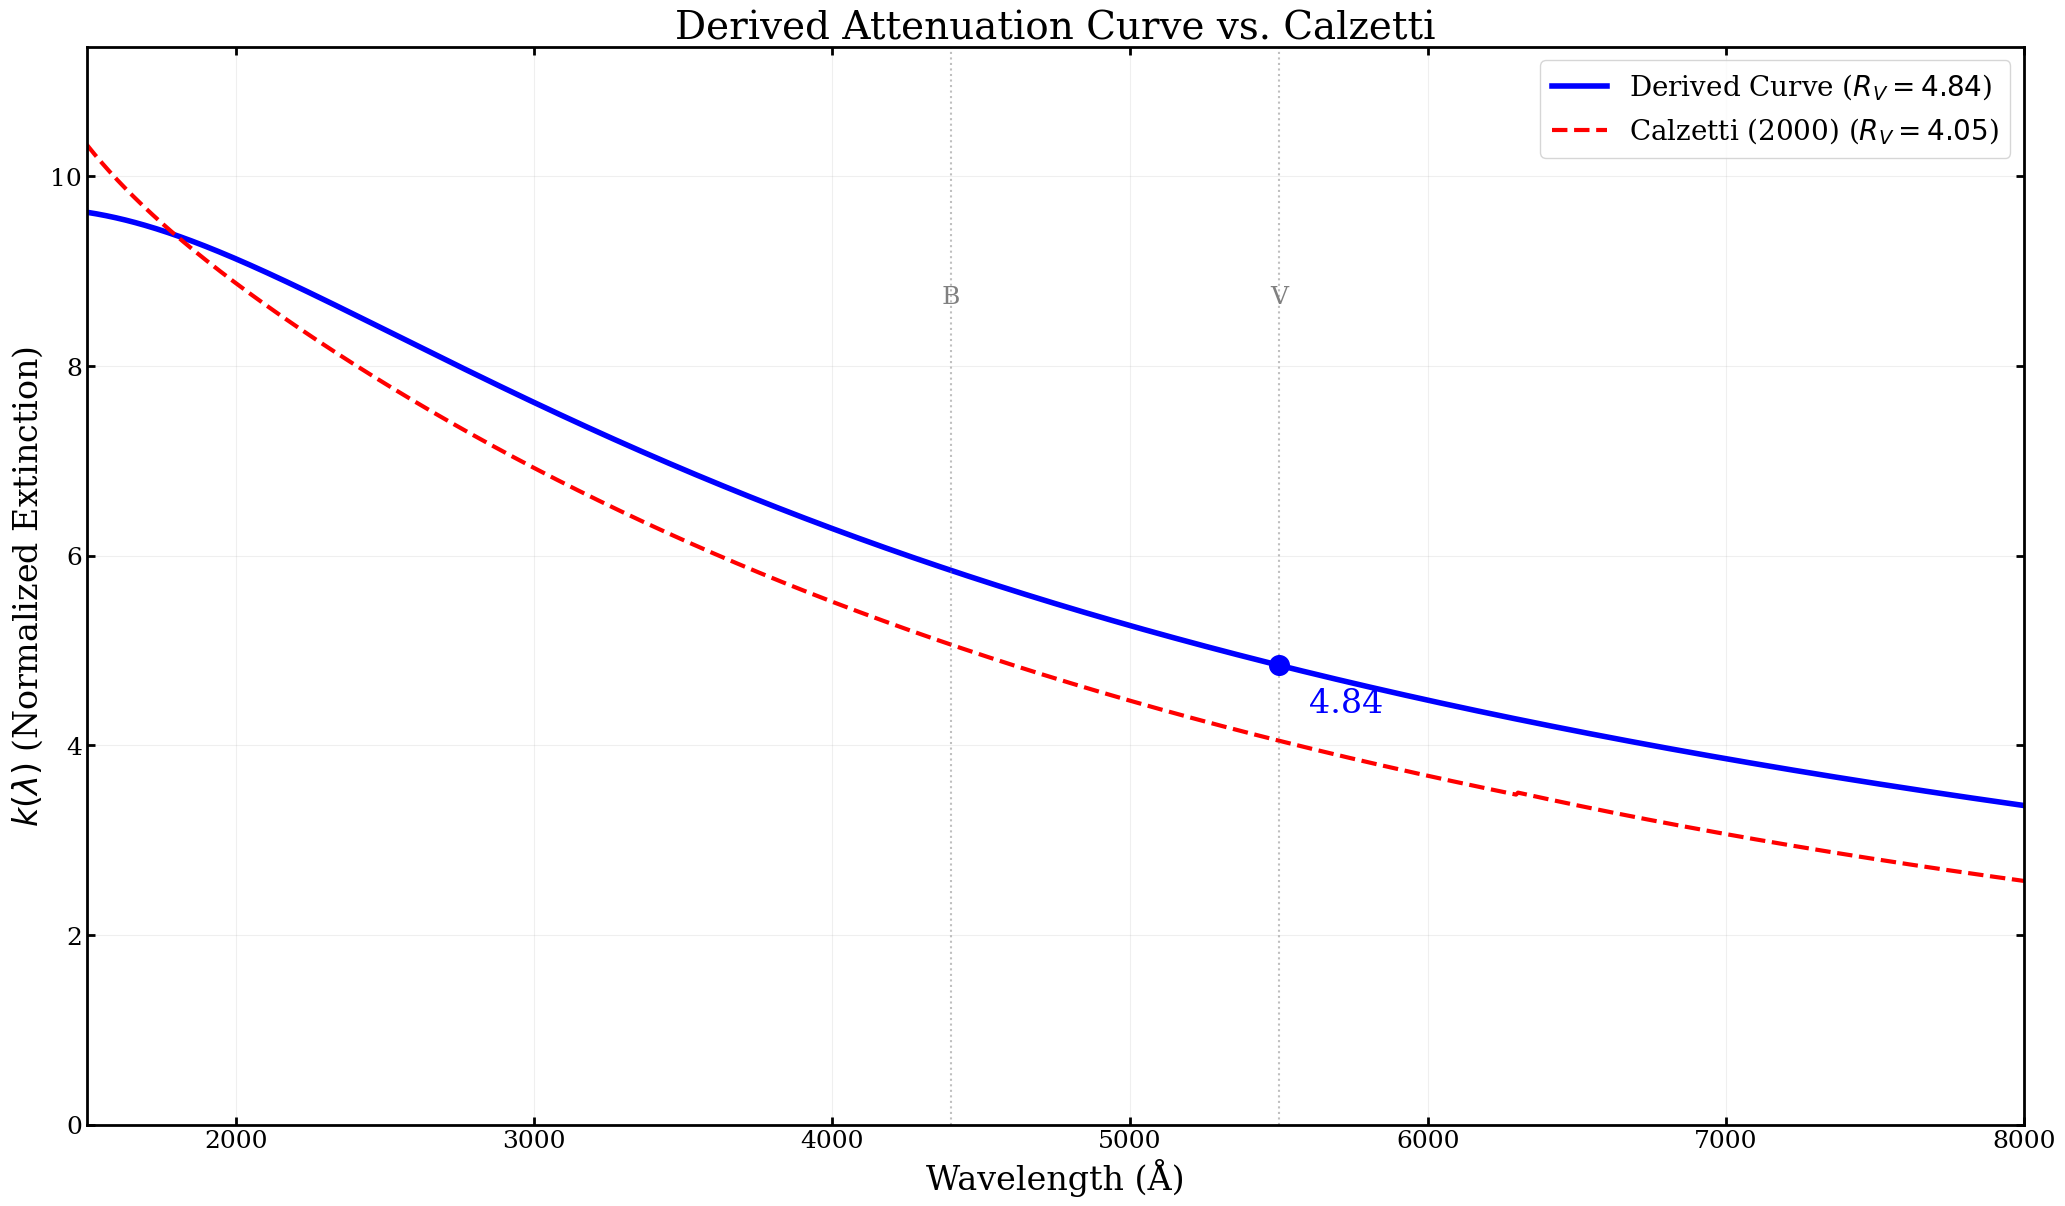

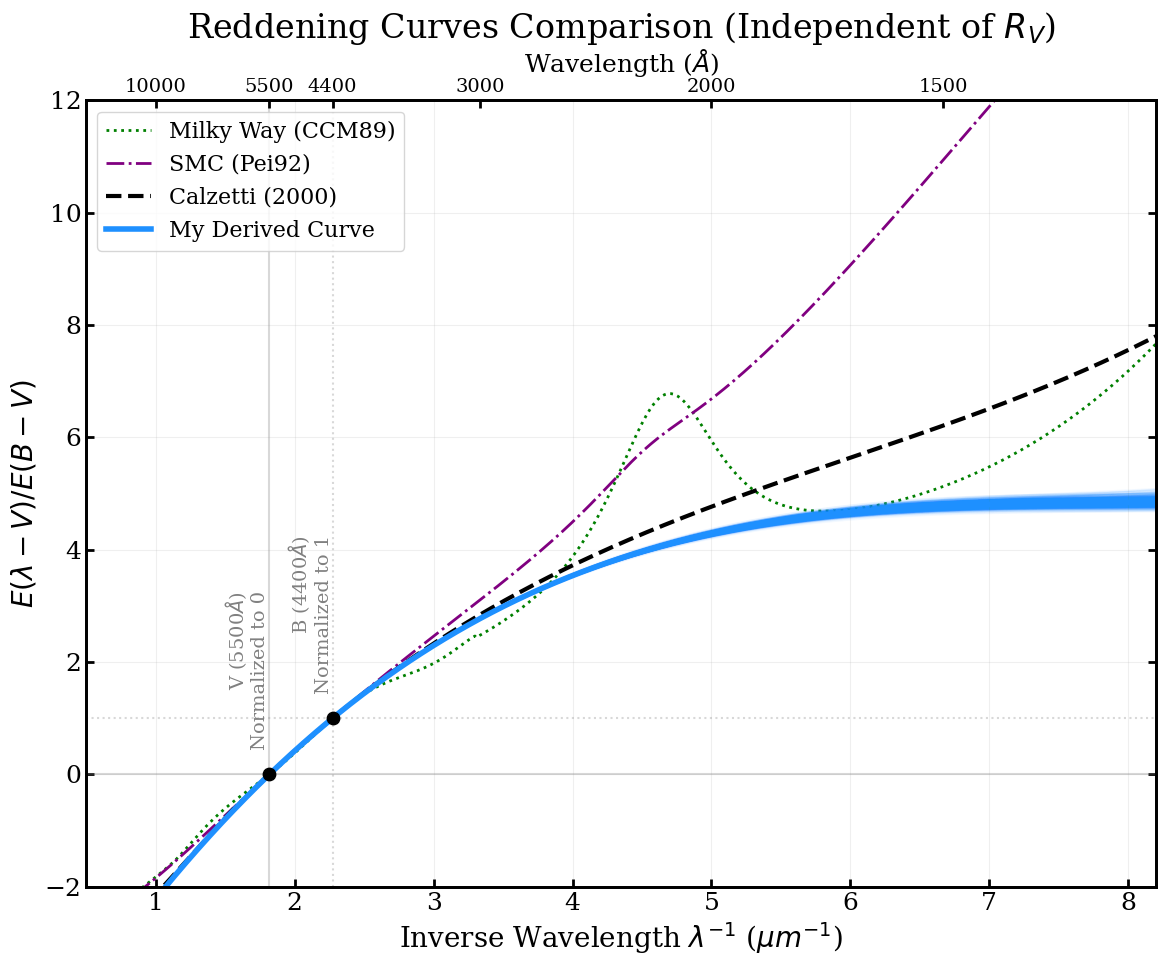

(<Figure size 1200x1000 with 2 Axes>,
 <Axes: title={'center': 'Reddening Curves Comparison (Independent of $R_V$)'}, xlabel='Inverse Wavelength $\\lambda^{-1}$ ($\\mu m^{-1}$)', ylabel='$E(\\lambda - V) / E(B - V)$'>)

In [3]:
# %%
# 1. 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
import corner  # 用于画 MCMC 的角图 (Corner Plot)

# 假设你的 Catalog 已经加载好了
# from FunctionLib import DJAv4Catalog ...

# 实例化分析器
analyst = FL.DustAttenuationAnalyst(DJAv4Catalog, wavelength_grid=(1350, 8000))

# %%
# 2. 准备数据 ID 列表
# 这一步根据你的筛选逻辑来，比如只选 Sample_Flag 为 True 的
target_ids = []
for survey_id, entry in DJAv4Catalog.catalog_iterator():
    # 这里可以加你的筛选条件
    if entry.get('sample_flag') is True:
        target_ids.append(survey_id)

print(f"Selected {len(target_ids)} targets for analysis.")

# %%
# 3. 运行基础管线 (Data Pipeline)
# 加载并分组
analyst.load_and_group_objects(target_ids)

# 计算平均光谱 (这一步会自动计算 average_flux_err)
analyst.compute_average_spectra()

# 计算平滑参考谱 (Group 0)
analyst.compute_smooth_reference(window_len=101, poly_order=3)

# %%
# 4. 计算 Q 曲线并进行误差传播 (关键步骤)
# mode='smoothed': 使用平滑后的参考谱，减少参考谱带来的噪声
# 这一步会自动利用之前的 flux_err 计算出 effective_curve_err
analyst.compute_attenuation_curves(mode='smoothed')

# 检查一下误差是否计算成功
if analyst.effective_curve_err is not None:
    print("Error propagation successful. Ready for MCMC.")
else:
    print("Warning: Error array is empty.")

# %%
# 5. 运行 MCMC 拟合 (Bayesian Inference)
# nwalkers: 游走者数量 (建议 32 或 64)
# nsteps: 步数 (建议 2000-5000，取决于收敛速度)
# poly_order: 拟合阶数 (通常 3 阶多项式对 1/lambda 足够)
analyst.run_mcmc_fitting(nwalkers=32, nsteps=3000, poly_order=3)

# 绘制 MCMC 拟合结果 (带 95% 误差带的蝴蝶结图)

analyst.plot_mcmc_results(plot_samples=True, n_samples=300)

# %%
# (可选) 绘制 Corner Plot 查看参数相关性
# 这有助于查看 c1, c2, c3 系数之间是否存在简并
if hasattr(analyst, 'mcmc_samples'):
    flat_samples = analyst.mcmc_samples
    labels = ["c3", "c2", "c1", "c0"] # 对应三次多项式系数
    fig = corner.corner(
        flat_samples,
        labels=labels,
        show_titles=True,
        title_fmt=".2f"
    )
    plt.show()

# %%
# 6. 推导物理参数 (Rv 和 Scaling Factor)
# 这一步会自动使用 MCMC 得到的最佳拟合系数 (中位数)
# 我们可以设定无穷远处的截距 (Calzetti Extrapolation ~ -0.89)
analyst.derive_k_curve_parameters(intercept_val=-0.89877)

# %%
# 7. 绘制最终的对比图 (Publication Quality)

# 7.1 绘制 k(lambda) 曲线 (Normalized Extinction Curve)
analyst.plot_derived_k_curve()

# 画红化曲线对比图，带100条猜测线
analyst.plot_reddening_curve_comparison(
    if_show=True,
    curve_label="My Derived Curve",
    curve_color="dodgerblue",
    plot_mcmc_samples=True,  # 开启绘制样本线
    n_samples=1000            # 画100条
)
# 保存图片
# fig.savefig("Final_Reddening_Curve.pdf", bbox_inches='tight')